# Model 3: Fine-tuned Sentence Transformer (bi-encoder)

Bi-encoder approach: encode question1 and question2 separately into embeddings, compare via cosine similarity. This is the same shape of pipeline as Model 0.2 (TF-IDF + cosine), but the sentence vectors come from a fine-tuned transformer instead of TF-IDF, so they should capture semantic similarity (synonyms, paraphrasing) rather than just exact word overlap.

Chosen over CrossEncoder because the intended real-world use case (a user types a question, check it against a large bank of existing questions -- e.g. for the Streamlit app) needs embeddings that can be precomputed once and compared via fast cosine similarity. A CrossEncoder can't precompute anything -- every comparison needs a full forward pass through the model, which doesn't scale to checking one new question against many existing ones.

Run this notebook in Google Colab with a GPU runtime (Runtime > Change runtime type > GPU).

## Setup

In [2]:
%pip install sentence-transformers

In [3]:
import sys
sys.path.append('..')

In [27]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, log_loss
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader
from sklearn.metrics.pairwise import paired_cosine_distances
from evaluation import train_and_evaluate, quick_log_loss
from sklearn.metrics import f1_score
from evaluation import compute_metrics, append_to_experiment_table, plot_confusion_matrix



### Load data and reuse the same train/val split

Upload `quora_with_features.csv` to the Colab session (or mount Drive). We only need the raw `question1`/`question2`/`is_duplicate` columns here -- the hand-crafted feature columns aren't used by this model -- but loading the same CSV with the same `train_test_split(test_size=0.2, stratify=y, random_state=42)` call as `02_baseline.ipynb`/`03_xgboost.ipynb` keeps the val set identical across all models, so metrics stay comparable in the experiment table.

In [6]:
raw_df = pd.read_csv('/content/quora_with_features.csv', index_col=0)

X = raw_df.drop(columns=['is_duplicate'])
y = raw_df['is_duplicate']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [7]:
raw_df.head(5)

,qid1,qid2,question1,question2,is_duplicate,question1_len,question2_len,len_dif,common_words,jaccard_similarity,word_match_share,bigrams_common,bigram_jaccard_similarity,bigram_word_match_share,cosine_similarity
id,,,,,,,,,,,,,,,
332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,0,47,81,-34,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
196656,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,62,55,7,3.0,0.600000,0.375000,1.0,0.200000,0.166667,0.827243
113125,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,32,78,-46,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.149953
266232,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,51,42,9,2.0,0.250000,0.200000,1.0,0.142857,0.125000,0.345153
122738,17811,27517,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1,159,68,91,4.0,0.235294,0.190476,1.0,0.055556,0.052632,0.233961


### Subsample for fine-tuning

Full train set is 400k+ pairs -- likely too slow to fine-tune fully within a Colab free-tier GPU session. Decide on a subsample size here (e.g. start small, confirm the approach beats TF-IDF cosine before scaling up the sample size / epoch count).

## Base model

Candidate starting point: `all-MiniLM-L6-v2` (384-dim, fast, strong general semantic-similarity performance). Load it via `SentenceTransformer(...)`.

In [8]:
ST_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [9]:
# Small stratified probe sample, just to measure step time (not for real training)
PROBE_SIZE = 500
BATCH_SIZE = 16

probe_df, _ = train_test_split(
    X_train.assign(is_duplicate=y_train),
    train_size=PROBE_SIZE,
    stratify=y_train,
    random_state=42,
)

probe_examples = [
    InputExample(texts=[row.question1, row.question2], label=float(row.is_duplicate))
    for row in probe_df.itertuples()
]
probe_loader = DataLoader(probe_examples, shuffle=True, batch_size=BATCH_SIZE)
probe_loss = losses.CosineSimilarityLoss(ST_model)

start = time.time()
ST_model.fit(
    train_objectives=[(probe_loader, probe_loss)],
    epochs=1,
    show_progress_bar=False,
)
elapsed = time.time() - start

n_steps = len(probe_loader)
sec_per_step = elapsed / n_steps
print(f'{elapsed:.1f}s for {n_steps} steps -> {sec_per_step:.3f}s/step at batch_size={BATCH_SIZE}')

# Extrapolate: for a candidate N_SAMPLE and EPOCHS, estimate total training time
for N_SAMPLE in [5_000, 10_000, 20_000, 50_000]:
    for EPOCHS in [1, 2, 3]:
        est_steps = (N_SAMPLE / BATCH_SIZE) * EPOCHS
        est_minutes = est_steps * sec_per_step / 60
        print(f'N_SAMPLE={N_SAMPLE:>6} epochs={EPOCHS} -> ~{est_minutes:.1f} min')

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

{'train_runtime': '3.319', 'train_samples_per_second': '150.7', 'train_steps_per_second': '9.642', 'train_loss': '0.238', 'epoch': '1'}
3.8s for 32 steps -> 0.118s/step at batch_size=16
N_SAMPLE=  5000 epochs=1 -> ~0.6 min
N_SAMPLE=  5000 epochs=2 -> ~1.2 min
N_SAMPLE=  5000 epochs=3 -> ~1.8 min
N_SAMPLE= 10000 epochs=1 -> ~1.2 min
N_SAMPLE= 10000 epochs=2 -> ~2.4 min
N_SAMPLE= 10000 epochs=3 -> ~3.7 min
N_SAMPLE= 20000 epochs=1 -> ~2.4 min
N_SAMPLE= 20000 epochs=2 -> ~4.9 min
N_SAMPLE= 20000 epochs=3 -> ~7.3 min
N_SAMPLE= 50000 epochs=1 -> ~6.1 min
N_SAMPLE= 50000 epochs=2 -> ~12.2 min
N_SAMPLE= 50000 epochs=3 -> ~18.4 min


In [10]:
#reloading model
ST_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Pick `N_SAMPLE` (and `EPOCHS`) from the table above based on your actual time budget, then draw the real stratified training subsample here.

In [11]:
N_SAMPLE = 20_000  # first check: small enough to be fast, enough to see if the method works at all
EPOCHS = 3

train_sample_df, _ = train_test_split(
    X_train.assign(is_duplicate=y_train),
    train_size=N_SAMPLE,
    stratify=y_train,
    random_state=42,
)

## Prepare training examples

`sentence-transformers` expects `InputExample(texts=[q1, q2], label=is_duplicate)` pairs built from the (subsampled) train split. `label` is 0/1 here and doubles as the target cosine similarity for the loss below.

In [12]:
train_examples = [
    InputExample(texts=[row.question1, row.question2], label=float(row.is_duplicate))
    for row in train_sample_df.itertuples()]

## Fine-tune

`CosineSimilarityLoss` fits directly: it pushes cosine similarity of the two embeddings toward the 0/1 label. Wrap the `InputExample`s in a `DataLoader`, then call `model.fit(...)` with this loss, a chosen batch size, and epoch count.

In [13]:
train_loader = DataLoader(train_examples, shuffle=True, batch_size=BATCH_SIZE)
train_loss = losses.CosineSimilarityLoss(ST_model)

warmup_steps = len(train_loader) * EPOCHS * 0.1
start = time.time()
ST_model.fit(
    train_objectives=[(train_loader, train_loss)],
    epochs=EPOCHS,
    warmup_steps=warmup_steps,
    show_progress_bar=False
)
elapsed = time.time() - start

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

{'loss': '0.1822', 'grad_norm': '1.594', 'learning_rate': '1.927e-05', 'epoch': '0.4'}
{'loss': '0.1465', 'grad_norm': '2.562', 'learning_rate': '1.63e-05', 'epoch': '0.8'}
{'loss': '0.1294', 'grad_norm': '1.63', 'learning_rate': '1.334e-05', 'epoch': '1.2'}
{'loss': '0.1177', 'grad_norm': '1.369', 'learning_rate': '1.038e-05', 'epoch': '1.6'}
{'loss': '0.117', 'grad_norm': '2.31', 'learning_rate': '7.413e-06', 'epoch': '2'}
{'loss': '0.1045', 'grad_norm': '1.756', 'learning_rate': '4.45e-06', 'epoch': '2.4'}
{'loss': '0.09908', 'grad_norm': '1.737', 'learning_rate': '1.487e-06', 'epoch': '2.8'}
{'train_runtime': '226.5', 'train_samples_per_second': '264.9', 'train_steps_per_second': '16.56', 'train_loss': '0.1262', 'epoch': '3'}


## Evaluate on the val split

Encode `question1`/`question2` from `X_val` with the fine-tuned model, compute pairwise cosine similarity (same shape of computation as `cosine_similarity` in `src/features.py`, just with these embeddings instead of TF-IDF vectors).

Then score it the same way as every other model in this project so results are directly comparable in the experiment table:
- either threshold the cosine similarity directly, the way Model 0.2 does (`compute_metrics(y_val, y_pred, cosine_sim, 'Model 3: Sentence Transformer', threshold=...)`)
- or feed cosine similarity as a feature into a small downstream classifier, if that turns out to work better

Use `compute_metrics` / `append_to_experiment_table` from `src/evaluation.py` (same functions used in `02_baseline.ipynb` and `03_xgboost.ipynb`) so the row lands in `reports/experiment_table.csv` in the same format as Models 0.1-2.

In [14]:
q1_embeddings_val = ST_model.encode(X_val['question1'].tolist(), show_progress_bar=True)
q2_embeddings_val = ST_model.encode(X_val['question2'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/818 [00:00<?, ?it/s]

Batches:   0%|          | 0/818 [00:00<?, ?it/s]

In [15]:
similarity_val = 1 - paired_cosine_distances(q1_embeddings_val, q2_embeddings_val)

In [19]:
q1_embeddings_train_sample = ST_model.encode(train_sample_df['question1'].tolist(), show_progress_bar=True)
q2_embeddings_train_sample = ST_model.encode(train_sample_df['question2'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/625 [00:00<?, ?it/s]

Batches:   0%|          | 0/625 [00:00<?, ?it/s]

In [20]:
similarity_train_sample = 1 - paired_cosine_distances(q1_embeddings_train_sample, q2_embeddings_train_sample)

In [25]:
#chosing of threshold

best_f1, best_threshold = 0, 0
for threshold in np.arange(0.1, 0.9, 0.05):
    y_pred_temp = (similarity_train_sample > threshold).astype(int)
    f1 = f1_score(train_sample_df['is_duplicate'], y_pred_temp)
    if f1 > best_f1:
        best_f1, best_threshold = f1, threshold

#prediction on val
y_pred = (similarity_val> best_threshold).astype(int)

In [28]:
y_pred_train = (similarity_train_sample > best_threshold).astype(int)
y_train_sample = train_sample_df['is_duplicate']

train_score = {
    'f1': f1_score(y_train_sample, y_pred_train),
    'roc_auc': roc_auc_score(y_train_sample, similarity_train_sample),
    'log_loss': log_loss(y_train_sample, similarity_train_sample),
}

results_model_3 = compute_metrics(y_val, y_pred, similarity_val, 'Model 3 - Sentence Transformer (bi-encoder)', threshold=best_threshold, train_score=train_score)

model: Model 3 - Sentence Transformer (bi-encoder)

threshold: 0.6000000000000002

params: None

train_time_sec: None

train_f1: 0.8830027779572324

train_roc_auc: 0.9637695967589314

train_log_loss: 0.2957160722222468

f1: 0.7811216849427564

roc_auc: 0.9055541785770572

log_loss: 0.42464752850832554



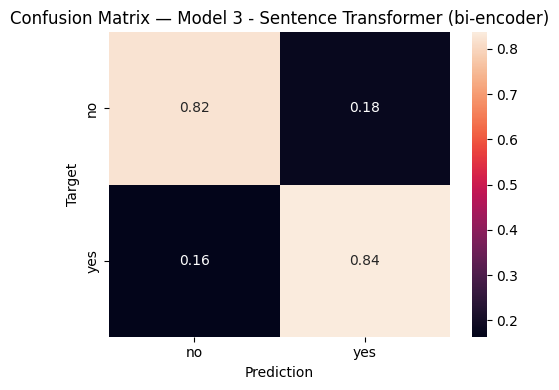

In [29]:
plot_confusion_matrix(y_val, y_pred, 'Model 3 - Sentence Transformer (bi-encoder)')


In [31]:
append_to_experiment_table(results_model_3, path='/content/experiment_table.csv')

## Save and bring back to the repo

- `model.save('path')` to persist the fine-tuned model (needed if this model is going to be used in the Streamlit app later)
- Download this notebook from Colab and replace `notebooks/04_sentence_transformers.ipynb` in the repo
- Append the results row to `reports/experiment_table.csv` (or copy it in manually if it was appended to a local CSV inside Colab instead of the repo path)